# Education Project: Predicting ACT Scores based on Socio-Economic Factors
### Brisa Halviatti for Data 5100 Assignment 2


Project Overview
* Objective: The goal of this project is to predict ACT scores of students using socioeconomic data about the school, location, and enviornment
* Domain: Education
* Key Techniques: Regression Analysis

## Load and Preview Datasources

In [149]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data visualization
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")
import plotly.offline as po
import plotly.graph_objs as pg
po.init_notebook_mode(connected=True)

# Model preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm
from patsy import dmatrices

Import Prepped Dataset

In [2]:
edgap = pd.read_excel(
    'https://raw.githubusercontent.com/brian-fischer/DATA-5100/main/EdGap_data.xlsx'
    ,dtype={'NCESSCH School ID': object})

C:\Users\brisa\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning:

Unknown extension is not supported and will be removed



Now we will focus on joining the referrals_arrests data. Just like before, it does not appear that the id we use in df (NCESSCHID) is always a match to combokey. We can check how we do, and create a backup plan to build it using leadid+schid+right(combokey,2) or use fuzzy logic on leaid and school name, but first let's see how close combokey gets us

In [76]:
combokeys = set(referrals_arrest['combokey'].unique())
ids = set(df_merged['id'].unique())

unmatched_keys = ids - combokeys  
print(f"{len(unmatched_keys)} keys are missing out of {len(ids)} from the df I want to left join on")

5125 keys are missing out of 7983 from the df I want to left join on


In [77]:
df_combokey = set(df_merged['combokey'].unique())

unmatched_keys2 = df_combokey - combokeys  
print(f"{len(unmatched_keys2)} keys are missing out of {len(ids)} from the df I want to left join on")

5006 keys are missing out of 7983 from the df I want to left join on


Interesting that we have a different number of matches using id vs combokey, when that was how we joined ccd to begin with. 

In [78]:
referrals_arrest.loc[referrals_arrest['sch_name']=='Delaware Military Academy']

,lea_state,leaid,schid,combokey,jj,sch_name,arrests,referrals
18235,DE,1000016,10001,100001600143,No,Delaware Military Academy,0.0,2.0


In [79]:
df_merged.loc[df_merged['sch_name']=='Delaware Military Academy']

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid,combokey,magnet_sch,shared_time_sch,area_description,student_cnt,teacher_cnt,student_teacher_ratio
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0,100001600143,2-No,2-No,21-Suburb: Large,584,25,23.36


In [80]:
referrals_arrest.loc[18235, 'combokey']

100001600143

In [81]:
df_merged.loc[0, 'id']

'100001600143'

Same issue! We need to turn referrals_arrest into a string as well:

In [82]:
df_merged['id'] = df_merged['id'].astype(str)
referrals_arrest['combokey'] = referrals_arrest['combokey'].astype(str)


In [83]:
combokeys = set(referrals_arrest['combokey'].unique())
ids = set(df_merged['id'].unique())

unmatched_keys = ids - combokeys  
print(f"{len(unmatched_keys)} keys are missing out of {len(ids)} from the df I want to left join on")

543 keys are missing out of 7983 from the df I want to left join on


In [84]:
df_combokey = set(df_merged['combokey'].unique())

unmatched_keys2 = df_combokey - combokeys  
print(f"{len(unmatched_keys2)} keys are missing out of {len(ids)} from the df I want to left join on")

425 keys are missing out of 7983 from the df I want to left join on


Still fascinated that there's somehow more data for combokey than id, when we used combokey from ccd_data to join to id in the first place -- but I will accept this for now, and use that to get more matches

In [85]:
df_merged2 = df_merged.merge(
    referrals_arrest[['combokey', 'jj', 'arrests', 'referrals']],
    how='left',
    on='combokey'
)


In [86]:
df_merged2.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid,combokey,magnet_sch,shared_time_sch,area_description,student_cnt,teacher_cnt,student_teacher_ratio,jj,arrests,referrals
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0,100001600143,2-No,2-No,21-Suburb: Large,584,25,23.36,No,0.0,2.0
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No,Middletown High School,1000080,1000024.0,100008000024,2-No,2-No,31-Town: Fringe,1499,87,17.23,No,4.0,46.0
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No,Appoquinimink High School,1000080,1000225.0,100008000225,2-No,2-No,41-Rural: Fringe,1638,95,17.24,No,0.0,24.0
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No,Cape Henlopen High School,1000170,1000029.0,100017000029,2-No,2-No,32-Town: Distant,1406,98,14.35,No,0.0,0.0
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No,Caesar Rodney High School,1000180,1000040.0,100018000040,2-No,2-No,22-Suburb: Mid-size,1996,134,14.9,No,8.0,56.0


Now we will add the zip codes with higher instutitions:

In [87]:
df_merged3 = df_merged2.merge(higher_ed_zip, how='left', on='zipcode')

In [88]:
no_institutions = df_merged3['institution_count'].isna() & df_merged3['zipcode'].notna()
df_merged3.loc[no_institutions, 'institution_count'] = 0

df_merged3['any_institutions'] = (df_merged3['institution_count'] > 0)
df_merged3.head(1)

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zipcode,school_type,school_level,charter,sch_name,leaid,schid,combokey,magnet_sch,shared_time_sch,area_description,student_cnt,teacher_cnt,student_teacher_ratio,jj,arrests,referrals,institution_count,any_institutions
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,Delaware Military Academy,1000016,1000143.0,100001600143,2-No,2-No,21-Suburb: Large,584,25,23.36,No,0.0,2.0,0.0,False


## Begin Analysis

Analyze the data using pairplots to start to assess relationships in the data

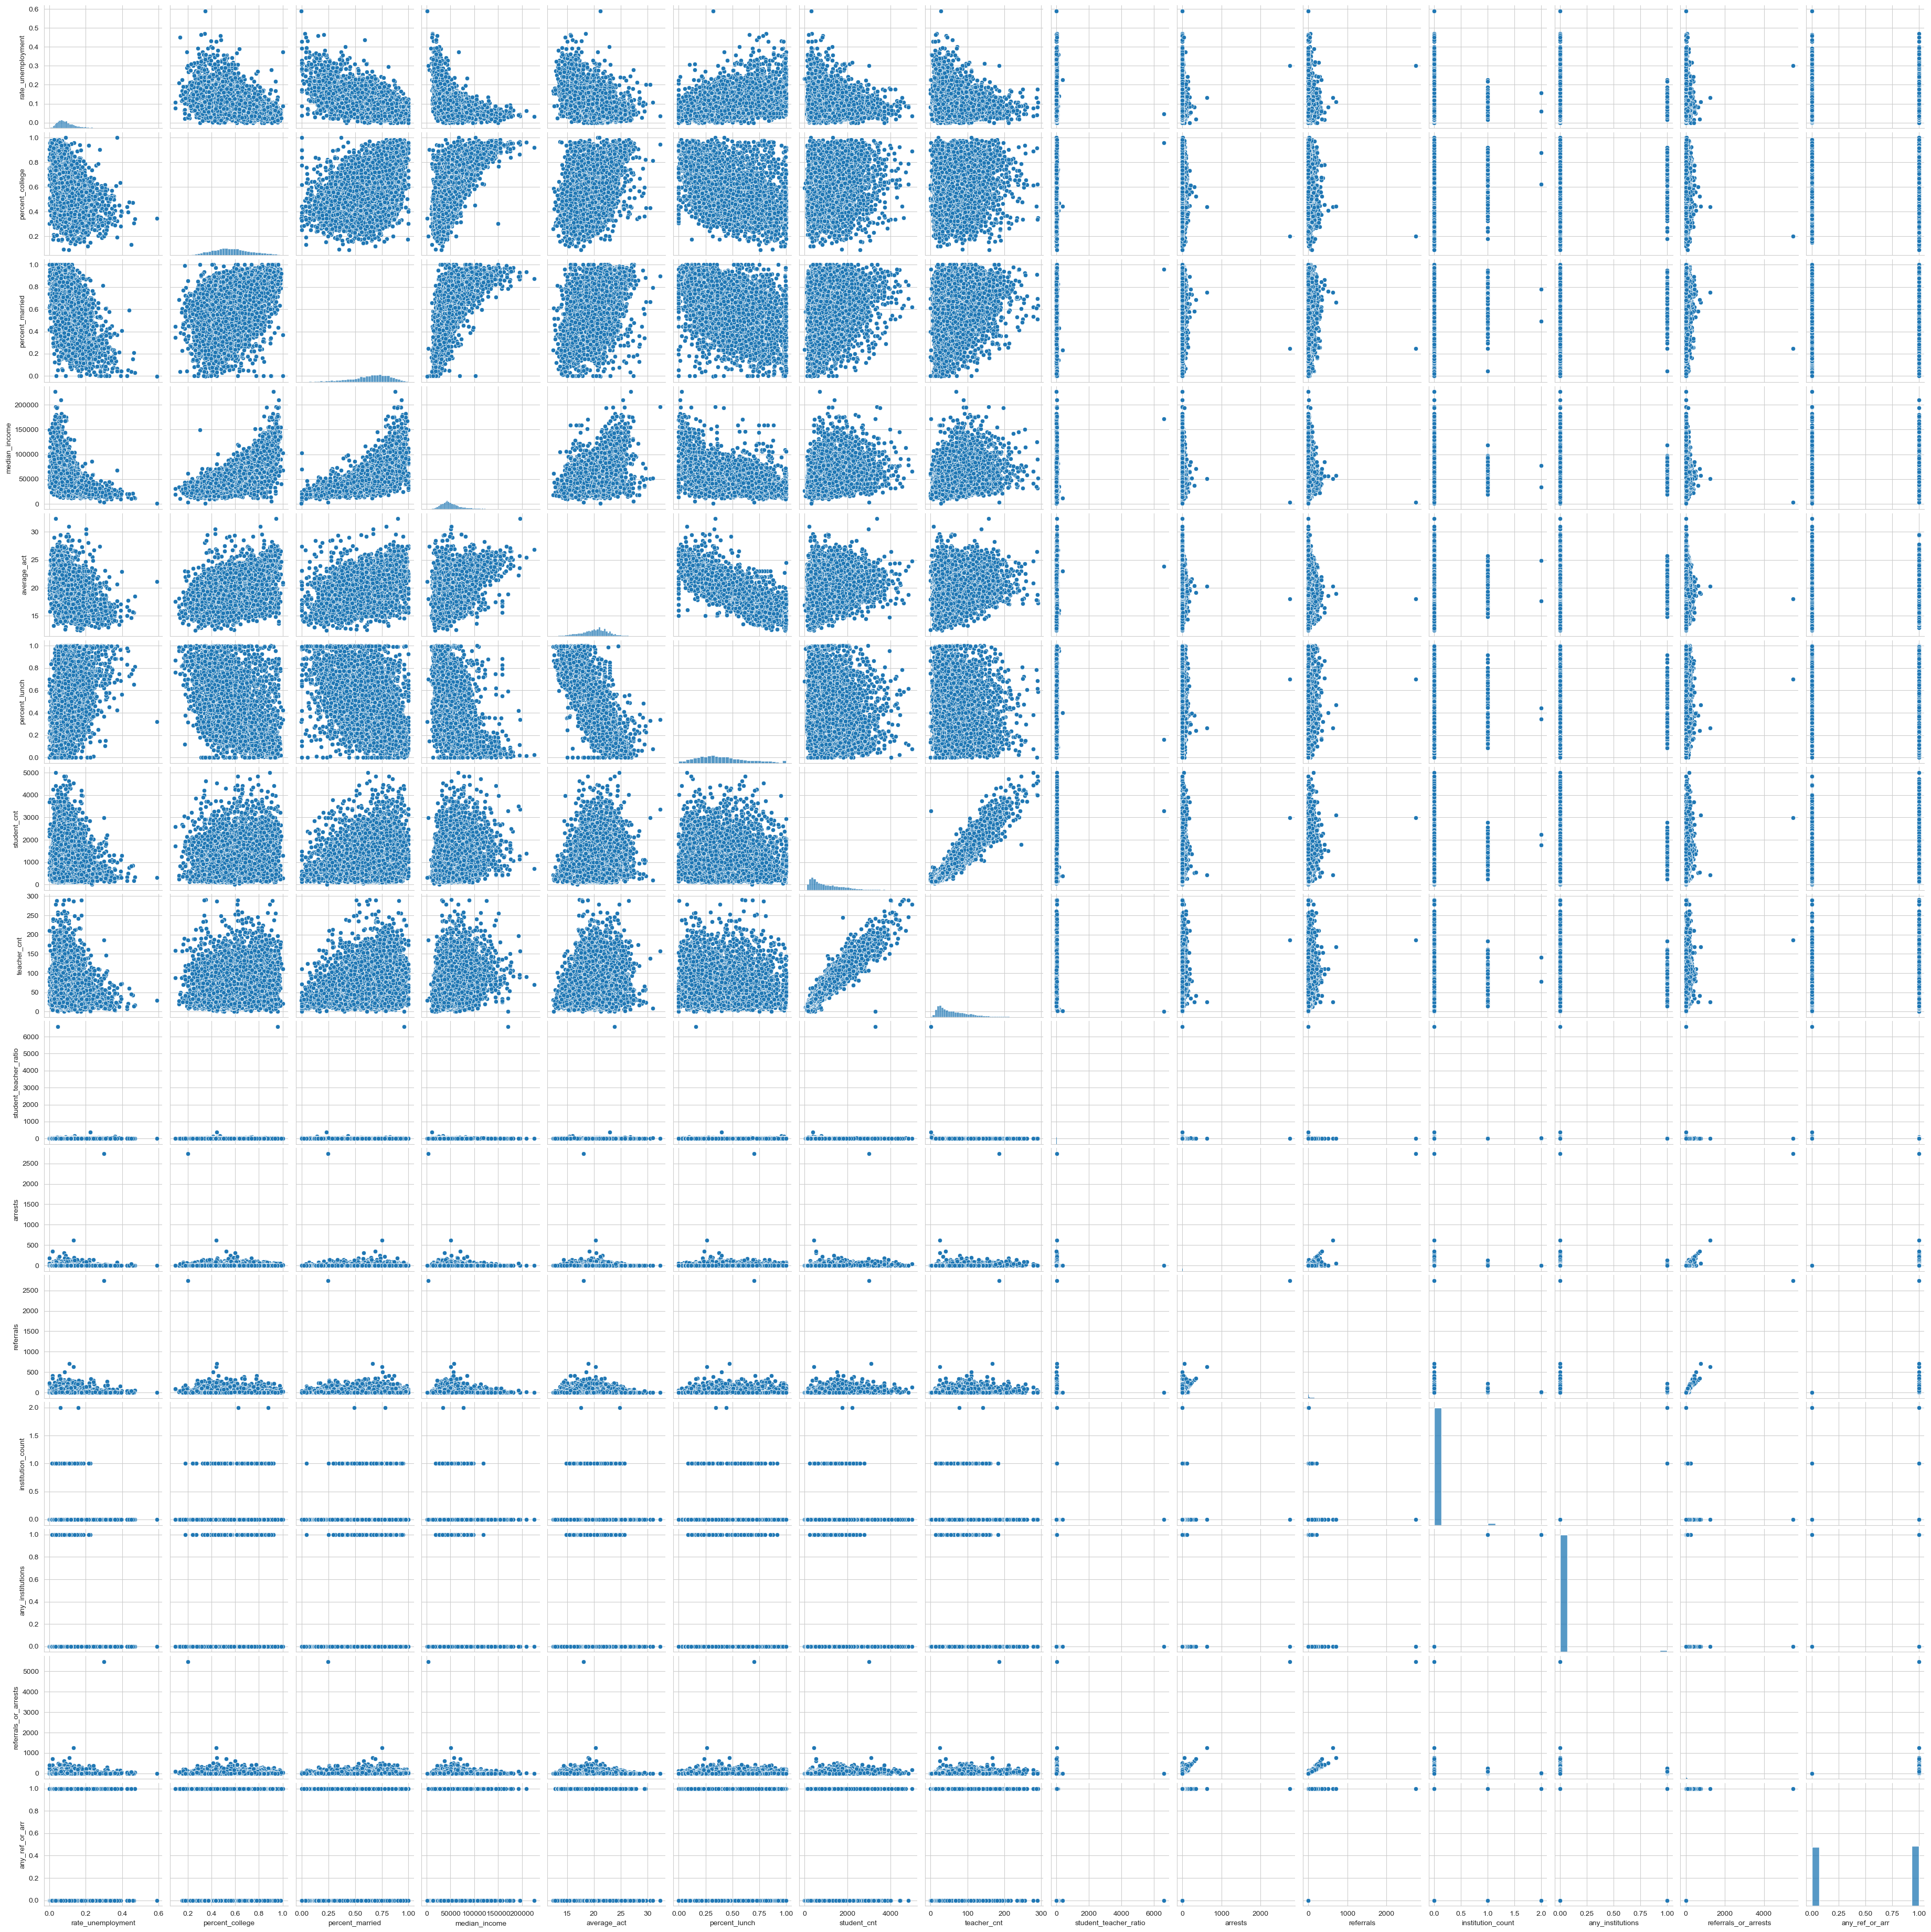

In [134]:
sns.pairplot(
    df_final
);
plt.show()

Zoom in on the variables for Average ACT, in two blocks:

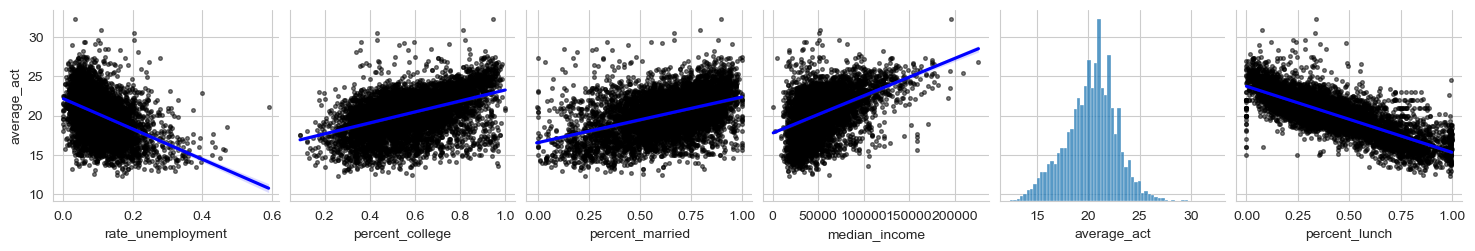

In [135]:
fig = sns.pairplot(
    df_final,
    y_vars=['average_act'],
    x_vars=['rate_unemployment',
 'percent_college',
 'percent_married',
 'median_income',
 'average_act',
 'percent_lunch'],  
    kind='reg',
    plot_kws={
        "line_kws": {'color':'blue'},
        "scatter_kws": {"alpha":0.5, "color":"k", "s":7},
    }
)


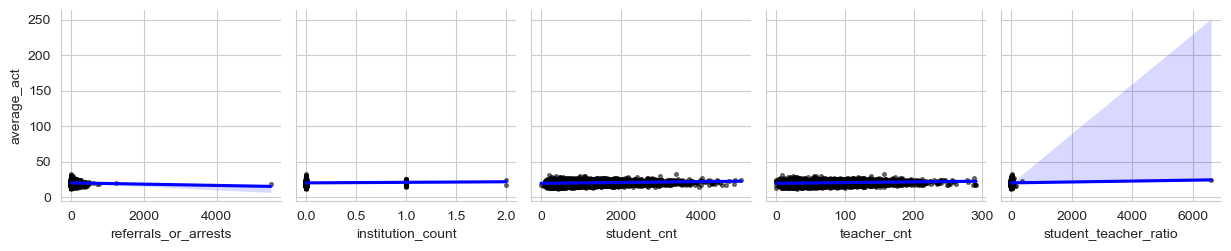

In [142]:
fig = sns.pairplot(
    df_final,
    y_vars=['average_act'],
    x_vars=['referrals_or_arrests', 'institution_count','student_cnt','teacher_cnt','student_teacher_ratio'],  
    kind='reg',
    plot_kws={
        "line_kws": {'color':'blue'},
        "scatter_kws": {"alpha":0.5, "color":"k", "s":7},
    }
)


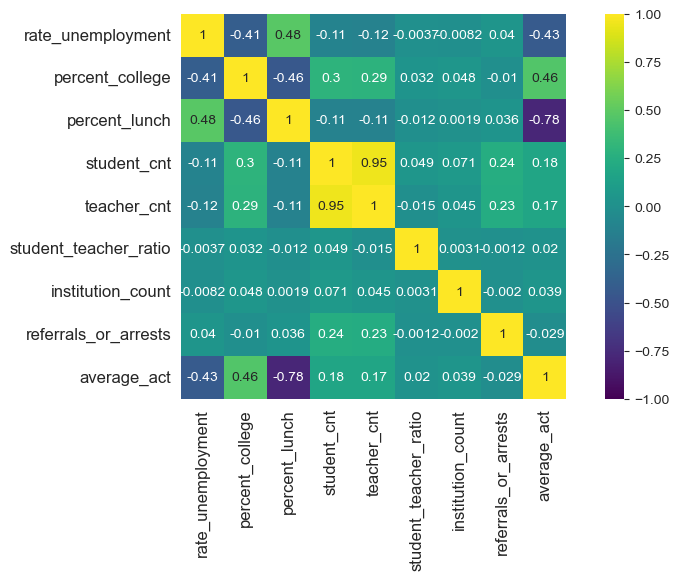

In [137]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_lunch', 'state', 'charter'
                       ,'magnet_sch','shared_time_sch','student_cnt','teacher_cnt','student_teacher_ratio'
                       ,'any_institutions','institution_count','testing','area_type','area_size','any_ref_or_arr','referrals_or_arrests']


numerical_predictors = df_final[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df_final[numerical_predictors + ["average_act"]].corr()

plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

#### Try some Categorical Analysis

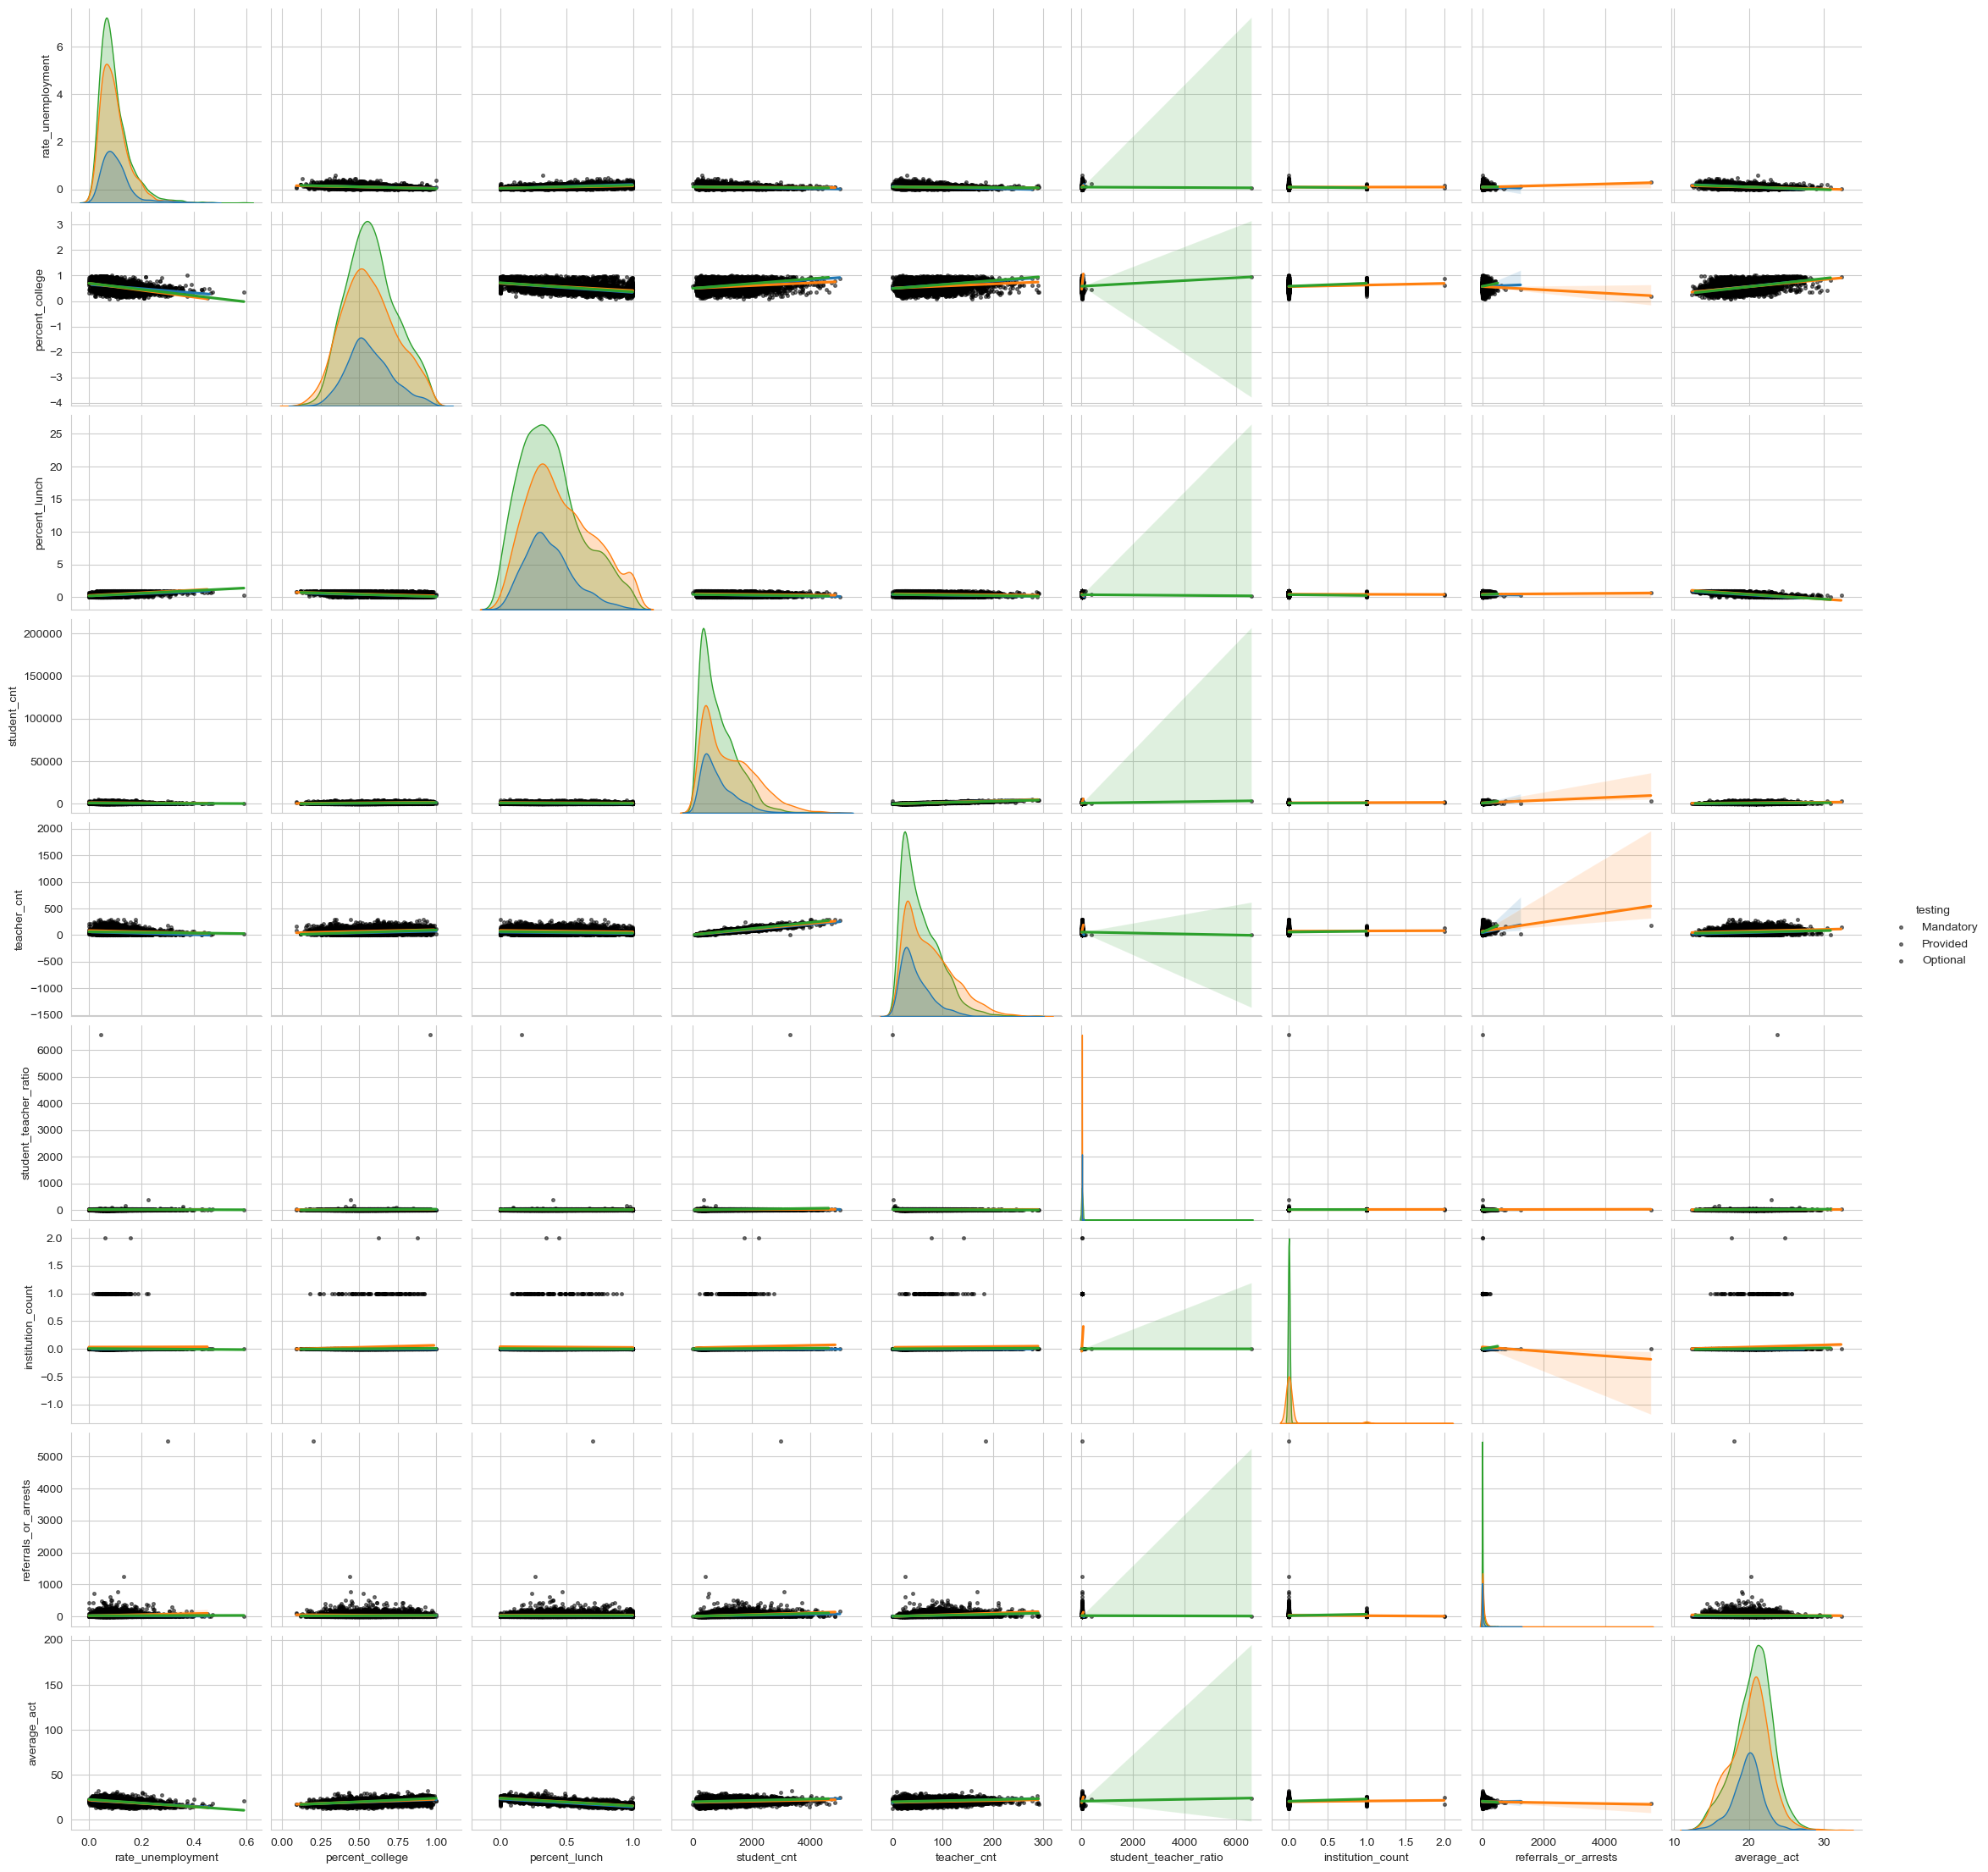

In [139]:
fig = sns.pairplot(
    data=df_final,
    vars=numerical_predictors + ['average_act'],
    hue='testing',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)
plt.show()

Some indication that scores are distributed differently based on whether tests are mandated or not

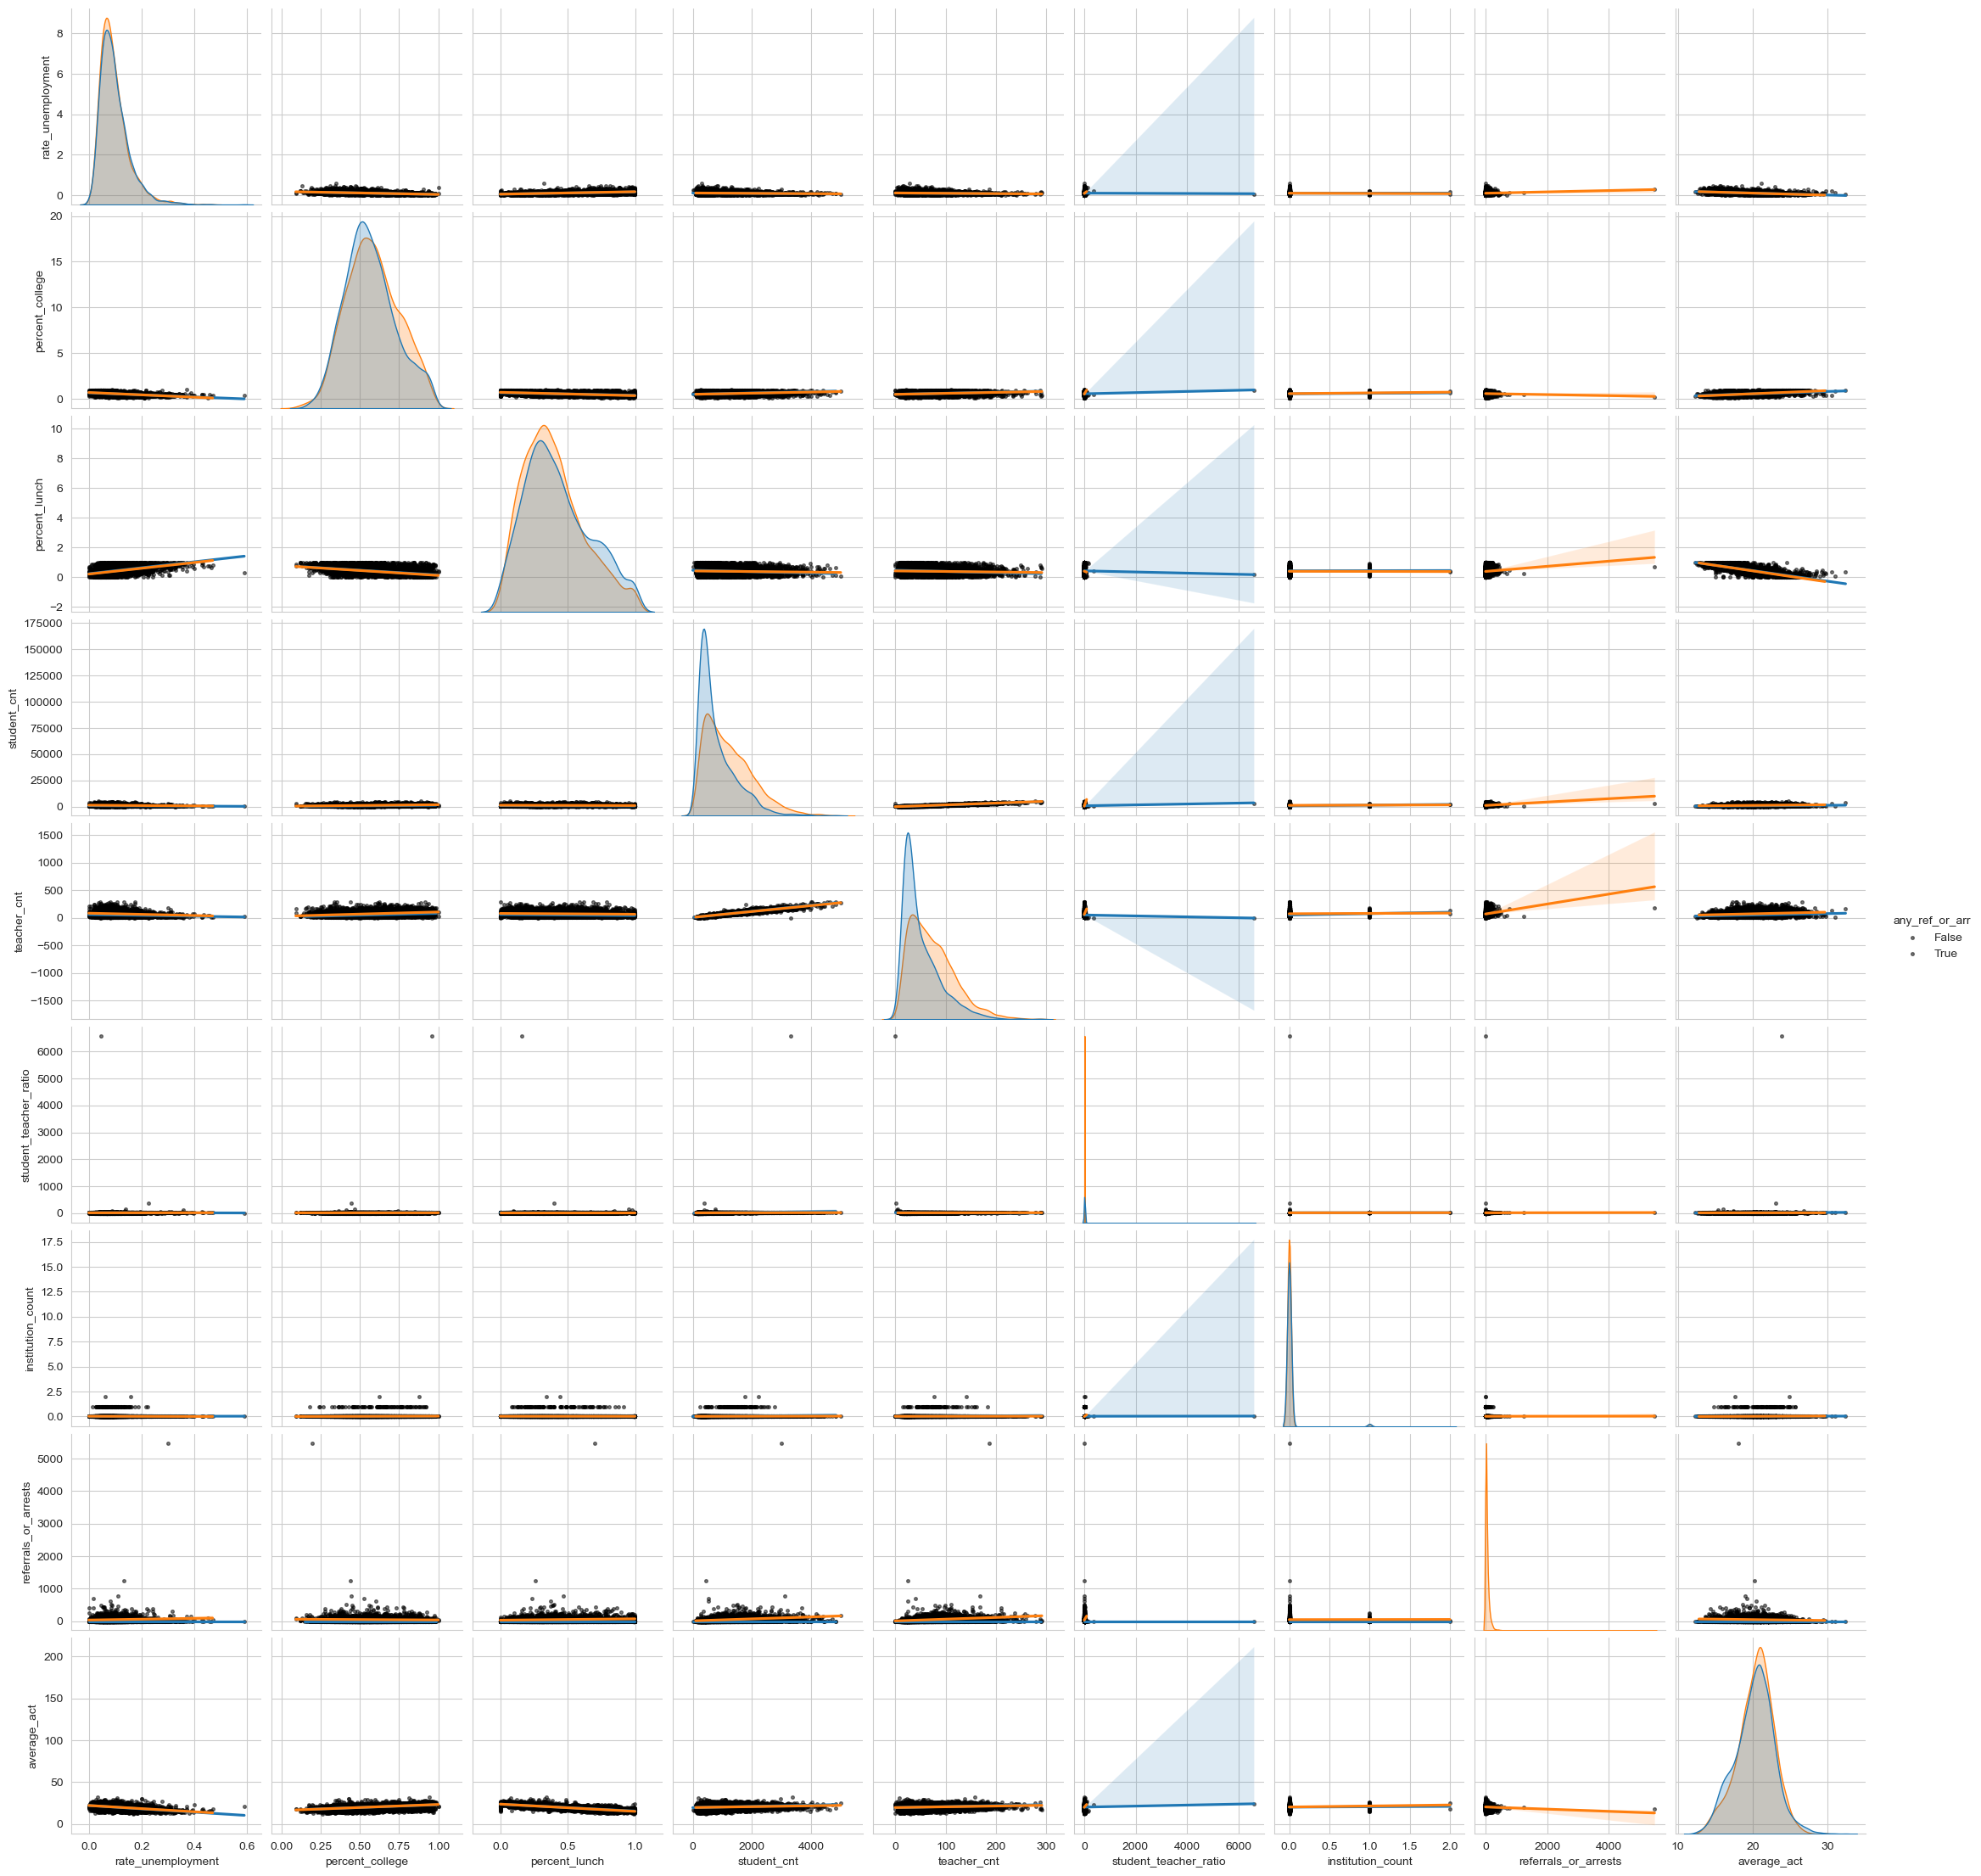

In [140]:
fig = sns.pairplot(
    data=df_final,
    vars=numerical_predictors + ['average_act'],
    hue='any_ref_or_arr',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)
plt.show()

Little indication that arrests and referrals influence much, probably due to so few

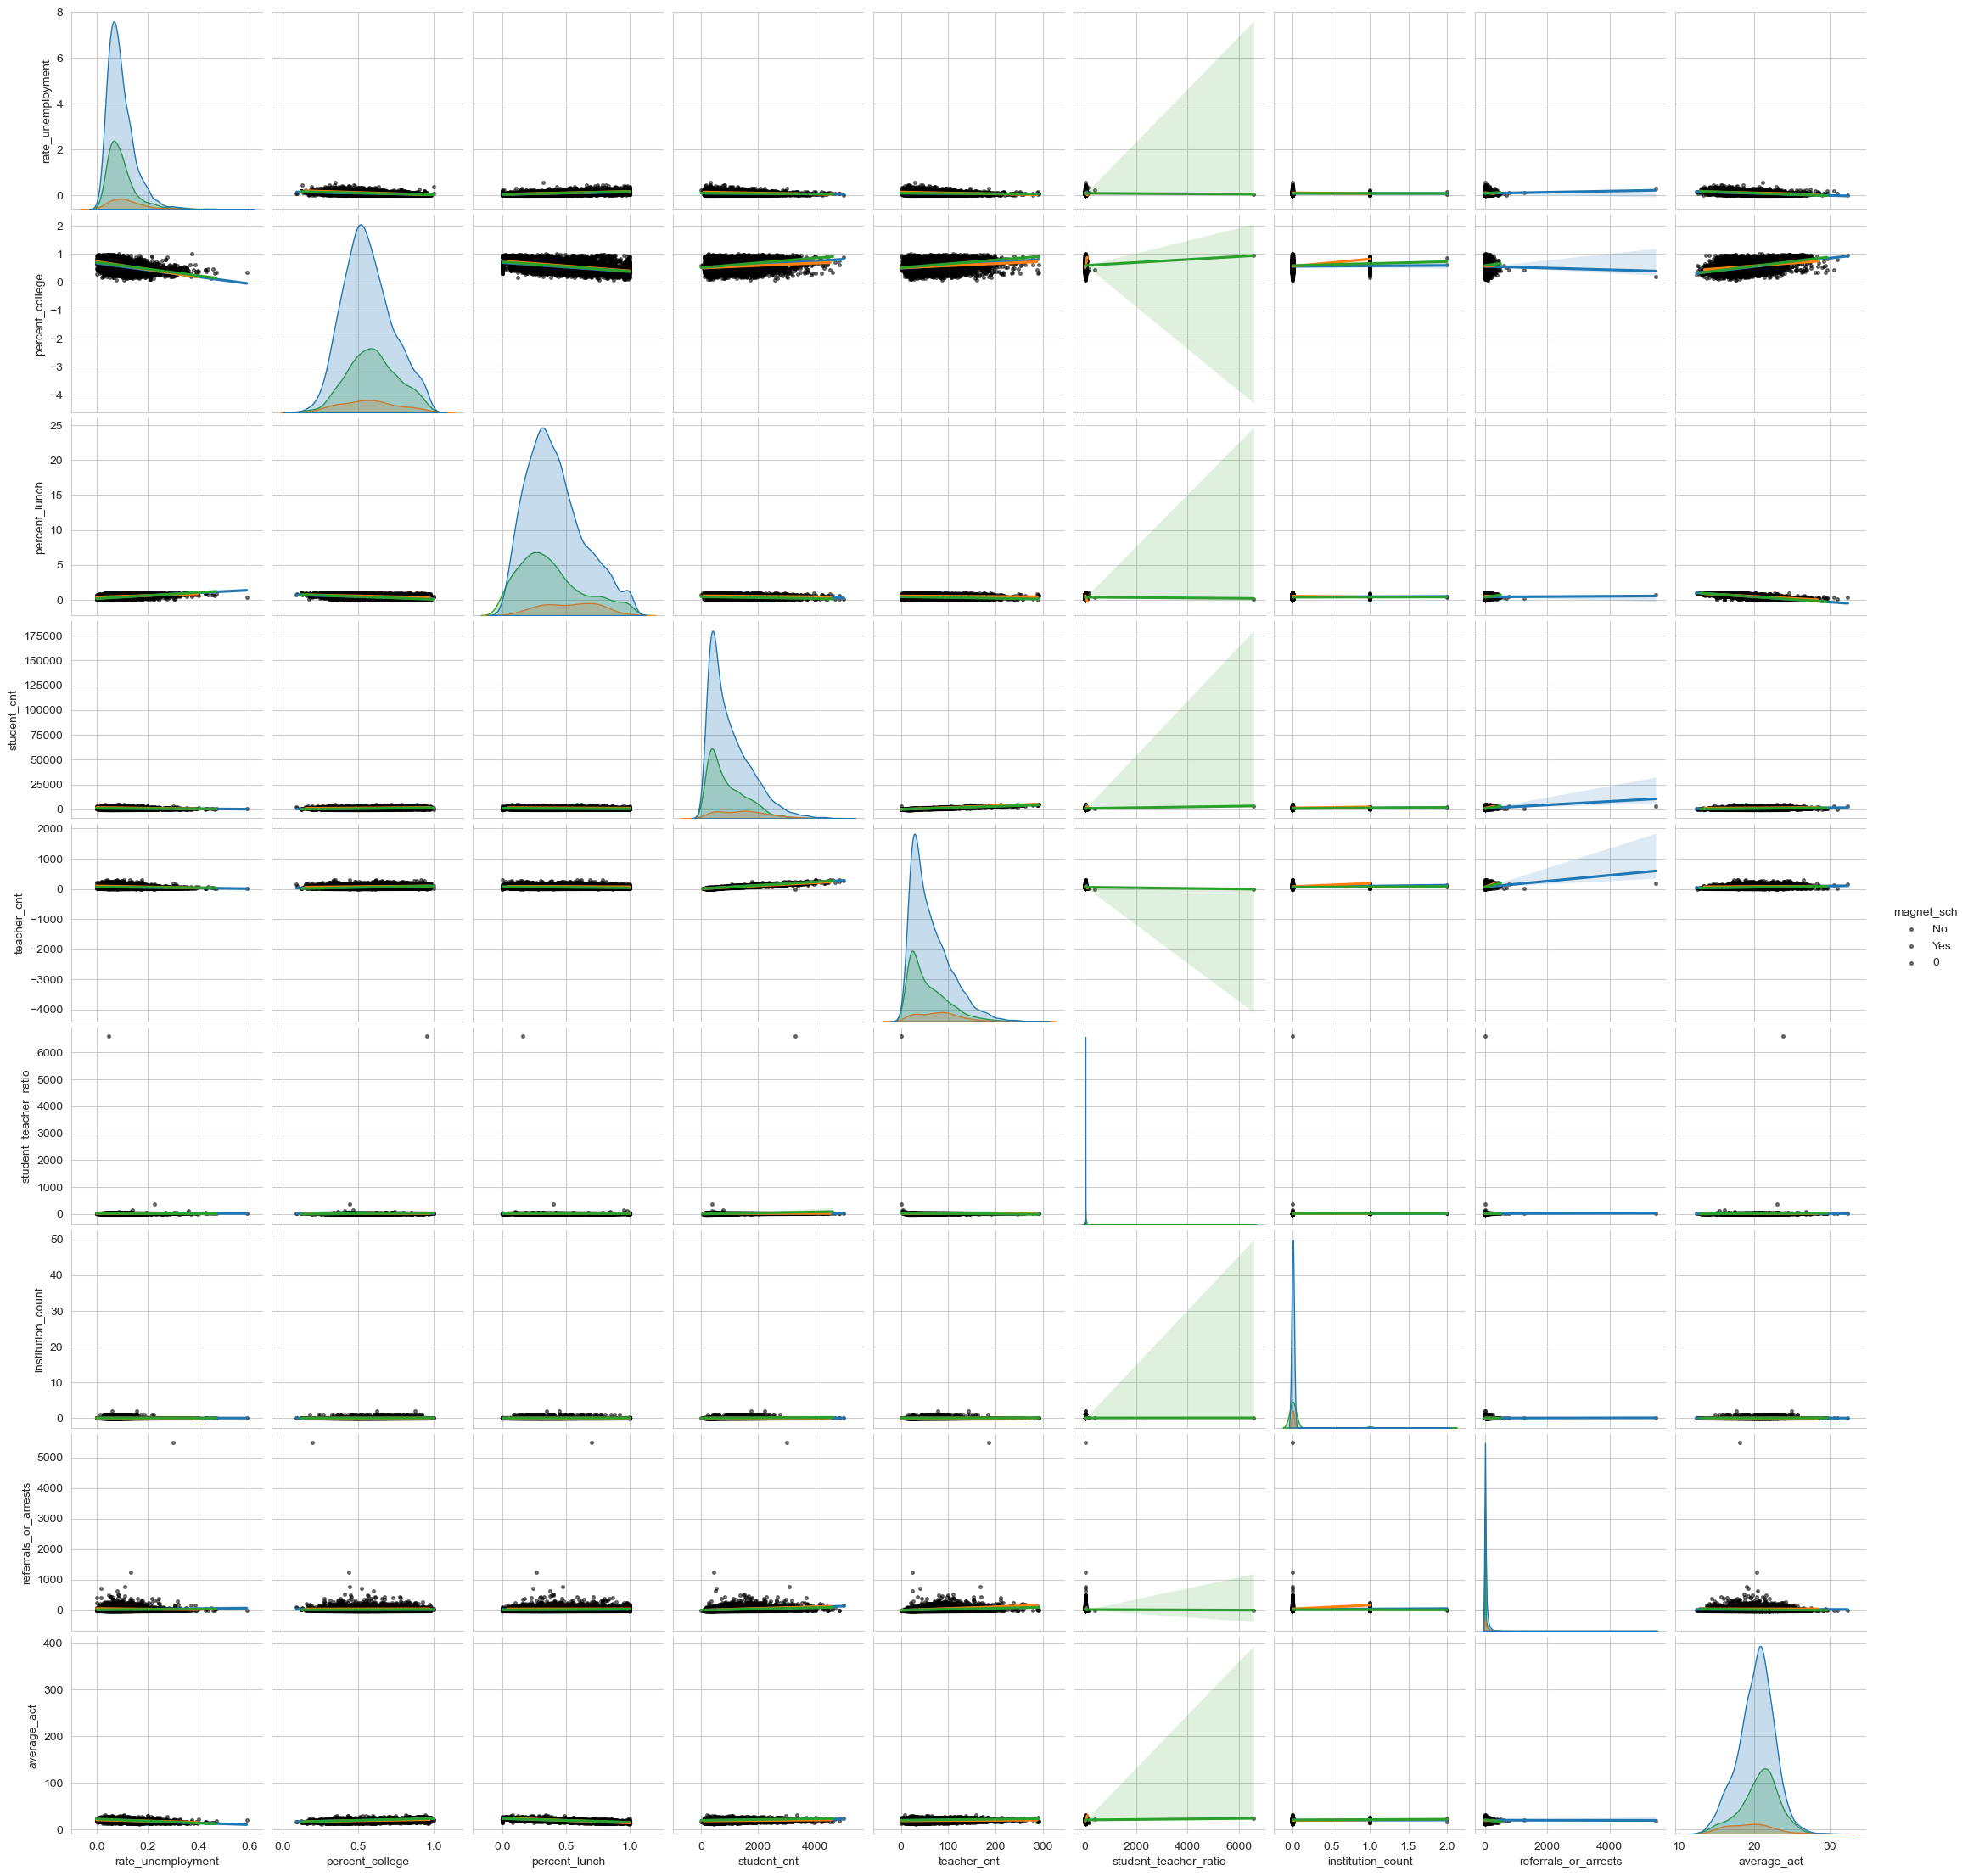

In [141]:
fig = sns.pairplot(
    data=df_final,
    vars=numerical_predictors + ['average_act'],
    hue='magnet_sch',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)
plt.show()

Again, probably too few "Magnet Schools" to make a significant difference, the distribution of ACT Scores is just slightly shifted but not by much

## Begin Multivariate Regression Model

We are going to start with a full model, then reduce the model until we have struck a balance of explanatory power without over fitting

In [153]:
multivariate_model = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch + student_cnt + teacher_cnt + student_teacher_ratio + institution_count + referrals_or_arrests + C(charter) + C(magnet_sch) + C(shared_time_sch) + C(testing) +  C(area_type) + C(area_size) + any_institutions + any_ref_or_arr',
    data=df_final).fit()


In [154]:
print(multivariate_model.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     548.5
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:45:59   Log-Likelihood:                -13007.
No. Observations:                7213   AIC:                         2.607e+04
Df Residuals:                    7187   BIC:                         2.625e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [155]:
y, X_design = dmatrices('average_act ~ rate_unemployment + percent_college + percent_lunch + student_cnt + teacher_cnt + student_teacher_ratio + institution_count + referrals_or_arrests + C(charter) + C(magnet_sch) + C(shared_time_sch) + C(testing) +  C(area_type) + C(area_size) + any_institutions + any_ref_or_arr',
                        data=df_final,
                        return_type='dataframe'
                        )

In [156]:
X_design.head()

,Intercept,C(charter)[T.Not applicable],C(charter)[T.Yes],C(magnet_sch)[T.No],C(magnet_sch)[T.Yes],C(shared_time_sch)[T.No],C(shared_time_sch)[T.Yes],C(testing)[T.Optional],C(testing)[T.Provided],C(area_type)[T.Rural],C(area_type)[T.Suburb],C(area_type)[T.Town],C(area_size)[T.Fringe],C(area_size)[T.Large],C(area_size)[T.Mid-size],C(area_size)[T.Remote],C(area_size)[T.Small],any_institutions[T.True],any_ref_or_arr[T.True],rate_unemployment,percent_college,percent_lunch,student_cnt,teacher_cnt,student_teacher_ratio,institution_count,referrals_or_arrests
0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.117962,0.445283,0.066901,584.0,25.0,23.36,0.0,2.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.063984,0.662765,0.112412,1499.0,87.0,17.23,0.0,50.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.056460,0.701864,0.096816,1638.0,95.0,17.24,0.0,24.0
3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.044739,0.692062,0.296960,1406.0,98.0,14.35,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.077014,0.640060,0.262641,1996.0,134.0,14.90,0.0,64.0


In [175]:
X = X_design.loc[:, multivariate_model.pvalues<0.05]

print(X.columns)

Index(['Intercept', 'C(magnet_sch)[T.No]', 'C(shared_time_sch)[T.No]',
       'C(shared_time_sch)[T.Yes]', 'C(testing)[T.Optional]',
       'C(testing)[T.Provided]', 'C(area_type)[T.Rural]',
       'C(area_type)[T.Town]', 'C(area_size)[T.Fringe]',
       'C(area_size)[T.Large]', 'C(area_size)[T.Mid-size]',
       'C(area_size)[T.Small]', 'any_ref_or_arr[T.True]', 'rate_unemployment',
       'percent_college', 'percent_lunch', 'student_cnt', 'teacher_cnt'],
      dtype='object')


In [176]:
multivariate_model_significant = sm.OLS(y, X).fit()

In [177]:
print(multivariate_model_significant.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.655
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     855.1
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:13:09   Log-Likelihood:                -13015.
No. Observations:                7213   AIC:                         2.606e+04
Df Residuals:                    7196   BIC:                         2.618e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

To reduce the model further, I will drop Student and Teacher counts, since this is essentially what comprises student-teacher ratio (which was ruled insignificant), and the coefficients for them are marginal at best. While statistically significant, I will also drop area_size since nearly all the values share the same coefficient with the exception of Fringe.

In [178]:
X = X.drop(
    columns=[
        #'C(area_size)[T.Fringe]',
        #'C(area_size)[T.Large]',
        #'C(area_size)[T.Mid-size]',
       # 'C(area_size)[T.Small]',
        'student_cnt', 'teacher_cnt'
    ]
)


In [179]:
multivariate_model_significant = sm.OLS(y, X).fit()

In [180]:
print(multivariate_model_significant.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     953.9
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:13:13   Log-Likelihood:                -13073.
No. Observations:                7213   AIC:                         2.618e+04
Df Residuals:                    7198   BIC:                         2.628e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

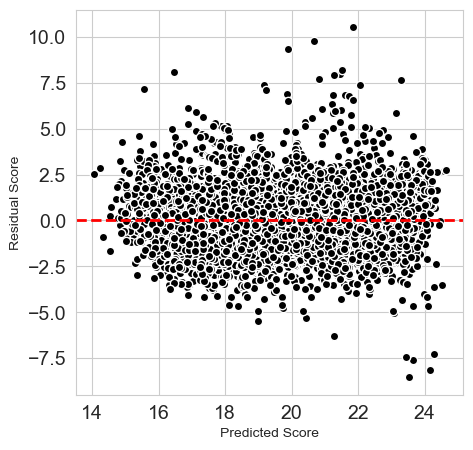

In [181]:
y_hat = multivariate_model_significant.predict()

plt.figure(figsize=(5,5))

plt.plot(y_hat, multivariate_model_significant.resid, 'ko',mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted Score')
plt.ylabel('Residual Score')

plt.tick_params(labelsize=14)

plt.show()

An ultra reduced model would look like this:

In [182]:
model_reduced = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch'
    ,data=df).fit()

In [183]:
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.623
Method:                 Least Squares   F-statistic:                     4405.
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:13:39   Log-Likelihood:                -14920.
No. Observations:                7983   AIC:                         2.985e+04
Df Residuals:                    7979   BIC:                         2.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.6971      0.09

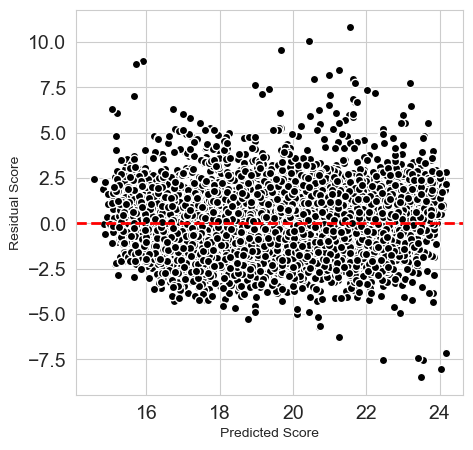

In [184]:
y_hat = model_reduced.predict()

plt.figure(figsize=(5,5))

plt.plot(y_hat, model_reduced.resid, 'ko',mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted Score')
plt.ylabel('Residual Score')

plt.tick_params(labelsize=14)

plt.show()

In [186]:
anova_lm(model_reduced,multivariate_model_significant)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,7979.0,19634.455816,0.0,NaN,NaN,NaN
1,7198.0,15845.003494,781.0,3789.452323,2.204169,1.900315e-61


We can see here that our residual sum of squares has reduced quite a bit, from 19.6k to to 15.8k. The P-value for our F Stat is extremely significant, but the F-stat itself is somewhat weak at 2.2. Ultimately, adding 781 degrees of freedom for a F-Stat smaller than 10 tells us the reduced model may still be the better option.